# Assignment_1_Dataset_A

## 1 Problem Definition_dataset A_auto price
### 1.1 Define a business or research problem (classification/regression) based on dataset A.
$~~$The Auto Prices dataset contains information about cars, including technical specifications, categorical attributes (like fuel type, body style), and numerical features (like engine size, horsepower, price)  
$~~$So, I treat it as a regression business issue where price is a continuous target variable.  
$~~$Problem: The problem is to predict the price of a car based on its attributes  
### 1.2 Identify relevant stakeholders and explain how they benefit from solving the problem.
$~~$Relevant stakeholders:   
$~~~~$Car marketplaces can use insights to adjust product design and pricing strategies.  
$~~~~$Used car dealers can assess fair resale values.  
$~~~~$Buyers can identify the key factors influencing price.  
$~~$Benefits:  
$~~~~$Accurate price prediction provides market transparency, supports decision-making, and can reduce information imbalance in the car market.

## 2 Data Description
### Conduct initial inspections of each dataset:
### 2.1 Number of attributes and instances

In [1]:
# Import necessary libraries
import pandas as pd

# Load the dataset
df = pd.read_csv("auto_price.csv") #Achieve the purpose of reading different datasets by changing the dataset name inside double quotes. 

# 2.1 Number of attributes and instances
print("Number of instances (rows):", df.shape[0])   # Print number of rows
print("Number of attributes (columns):", df.shape[1])  # Print number of columns

Number of instances (rows): 18286
Number of attributes (columns): 24


### 2.2 Data types of each attribute

In [8]:
# 2.2 Data types of each attribute
print("Data types of each attribute:")
print(df.dtypes)   # Show data types of each column

Data types of each attribute:
Unnamed: 0               int64
Make_Model              object
Body_Type               object
Price                   object
Vat                     object
Mileage                 object
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Extras                  object
Safety_Security         object
Age                    float64
Previous_Owners        float64
Horsepower              object
Inspection_New         float64
Paint_Type              object
Upholstery_Type         object
Gearing_Type            object
Displacement            object
Weight                  object
Drive_Chain             object
Cons_Comb              float64
dtype: object


### 2.3 Presence and proportion of missing values

In [16]:
# 2.3 Presence and proportion of missing values
missing_counts = df.isnull().sum()  # Number of missing values per column
missing_ratio = (missing_counts / len(df)) * 100  # Missing values proportion

# Combine counts and ratio into one table
missing_table = pd.DataFrame({"Missing Values": missing_counts, "Missing Ratio (%)": missing_ratio})
print("Missing values summary:")
print(missing_table)  #Present findings clearly using tables or visualisations where appropriate

Missing values summary:
                     Missing Values  Missing Ratio (%)
Unnamed: 0                        0           0.000000
Make_Model                     2194          11.998250
Body_Type                      2194          11.998250
Price                          3291          17.997375
Vat                            6400          34.999453
Mileage                        1645           8.995953
Type                           3840          20.999672
Fuel                           7131          38.997047
Gears                          5120          27.999563
Comfort_Convenience            4205          22.995734
Entertainment_Media            9691          52.996828
Extras                        15543          84.999453
Safety_Security               13165          71.994969
Age                            1280           6.999891
Previous_Owners                8411          45.996938
Horsepower                     1280           6.999891
Inspection_New                 6400      

### 2.4 Unique values in categorical feature

In [17]:
# 2.4 Unique values in categorical features
# Select categorical (object type) columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("\nUnique values in categorical features:")
for col in categorical_columns:
    unique_vals = df[col].nunique()  # Number of unique values
    print(f"{col}: {unique_vals} unique values")   # Print result


Unique values in categorical features:
Make_Model: 9 unique values
Body_Type: 8 unique values
Price: 4541 unique values
Vat: 2 unique values
Mileage: 7507 unique values
Type: 5 unique values
Fuel: 4 unique values
Comfort_Convenience: 5289 unique values
Entertainment_Media: 290 unique values
Extras: 267 unique values
Safety_Security: 1940 unique values
Horsepower: 84 unique values
Paint_Type: 3 unique values
Upholstery_Type: 2 unique values
Gearing_Type: 3 unique values
Displacement: 64 unique values
Weight: 922 unique values
Drive_Chain: 3 unique values


## 3 Data Cleaning and Processing

In [18]:
import pandas as pd  # data handling
import numpy as np  # numerical calculations
import matplotlib.pyplot as plt  # visualization

# Load dataset
df = pd.read_csv("auto_price.csv")

### 3.1 Identify data quality issues (e.g., missing values, redundant features, incorrect types, invalid entries).

In [19]:
# 3.1 Identify data quality issues
# Check data types
print("Data types before cleaning:")
print(df.dtypes)

# Check missing values
missing_summary = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values summary (Top 10):")
print(missing_summary.head(10))

Data types before cleaning:
Unnamed: 0               int64
Make_Model              object
Body_Type               object
Price                   object
Vat                     object
Mileage                 object
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Extras                  object
Safety_Security         object
Age                    float64
Previous_Owners        float64
Horsepower              object
Inspection_New         float64
Paint_Type              object
Upholstery_Type         object
Gearing_Type            object
Displacement            object
Weight                  object
Drive_Chain             object
Cons_Comb              float64
dtype: object

Missing values summary (Top 10):
Extras                 15543
Upholstery_Type        15177
Safety_Security        13165
Paint_Type             10423
Entertainment_Media     9691
Previous_Owners         8411
Fuel  

### 3.2 Apply appropriate cleaning strategies and justify your choices.

In [31]:
# 3.2 Apply cleaning strategies
# 1. Price: Remove "$" and "," and convert to numeric
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# 2. Mileage: Convert all mileage to km
df["Mileage"] = df["Mileage"].astype(str).str.replace(",", "", regex=False)
mi_mask = df["Mileage"].str.contains("mi", na=False)
km_mask = df["Mileage"].str.contains("km", na=False)
df.loc[mi_mask, "Mileage"] = pd.to_numeric(df.loc[mi_mask, "Mileage"].str.replace("mi", "", regex=False), errors="coerce") * 1.60934
df.loc[km_mask, "Mileage"] = pd.to_numeric(df.loc[km_mask, "Mileage"].str.replace("km", "", regex=False), errors="coerce")
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

# 3. Horsepower: Remove "kW"
df["Horsepower"] = df["Horsepower"].astype(str).str.replace("kW", "", regex=False)
df["Horsepower"] = pd.to_numeric(df["Horsepower"], errors="coerce")

# 4. Displacement: Remove "cc"
df["Displacement"] = df["Displacement"].astype(str).str.replace("cc", "", regex=False)
df["Displacement"] = pd.to_numeric(df["Displacement"], errors="coerce")

# 5. Weight: Convert all weights to kg
df["Weight"] = df["Weight"].astype(str)
kg_mask = df["Weight"].str.contains("kg", na=False)
lb_mask = df["Weight"].str.contains("lb", na=False)
df.loc[kg_mask, "Weight"] = pd.to_numeric(df.loc[kg_mask, "Weight"].str.replace("kg", "", regex=False), errors="coerce")
df.loc[lb_mask, "Weight"] = pd.to_numeric(df.loc[lb_mask, "Weight"].str.replace("lbs", "", regex=False), errors="coerce") * 0.453592
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")

# 6. Fuel: Standardize "Benzine" to "Petrol"
if "Fuel" in df.columns:
    df["Fuel"] = df["Fuel"].replace({"Benzine": "Petrol"})

# 7. use median to impute missing values, like Age and Previous_Owners
for col in ["Age", "Previous_Owners"]:
    if col in df.columns:
        df[col] = df[col].fillna(np.median(df[col].dropna()))

print("Data types after cleaning:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Data types after cleaning:
Make_Model              object
Body_Type               object
Price                  float64
Vat                     object
Mileage                float64
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Age                    float64
Previous_Owners        float64
Horsepower               int64
Inspection_New         float64
Paint_Type              object
Gearing_Type            object
Displacement           float64
Weight                   int64
Drive_Chain             object
Cons_Comb              float64
Power_to_Weight        float64
Age_Group               object
Mileage_per_Year       float64
dtype: object

Missing values after cleaning:
Paint_Type             10423
Price                  10175
Entertainment_Media     9691
Fuel                    7131
Inspection_New          6400
Vat                     6400
Drive_Chain             6034
Gears      

### 3.3 Ensure data is ready for modelling in 2


Data types after cleaning:
Make_Model              object
Body_Type               object
Price                  float64
Vat                     object
Mileage                float64
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Age                    float64
Previous_Owners        float64
Horsepower               int64
Inspection_New         float64
Paint_Type              object
Gearing_Type            object
Displacement           float64
Weight                   int64
Drive_Chain             object
Cons_Comb              float64
dtype: object

Remaining missing values (Top 10):
Paint_Type             10423
Price                  10175
Entertainment_Media     9691
Fuel                    7131
Vat                     6400
Inspection_New          6400
Drive_Chain             6034
Gears                   5120
Displacement            4937
Comfort_Convenience     4205
dtype: int64

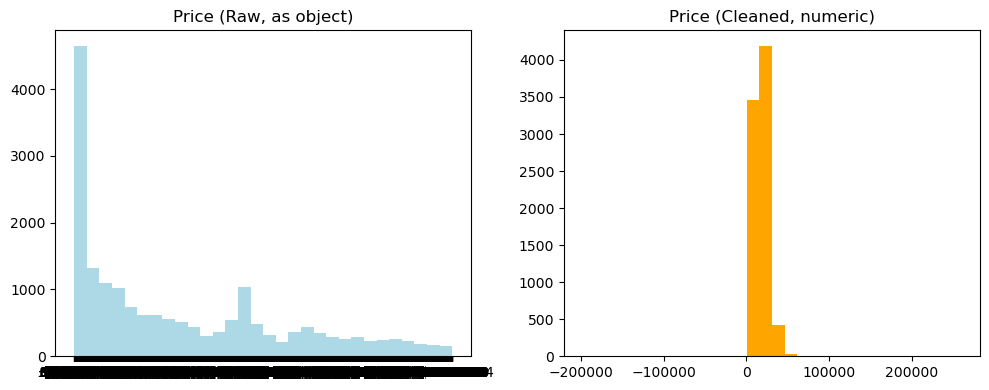

In [24]:
# 3.3 Ensure dataset is ready for modelling
print("\nData types after cleaning:")
print(df.dtypes)
print("\nRemaining missing values (Top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# view of Price distribution before vs after cleaning
plt.figure(figsize=(10,4))

# use dropna to avoid NaN before cleaning
plt.subplot(1,2,1)
df_raw = pd.read_csv("auto_price.csv")
plt.hist(df_raw["Price"].astype(str).str.replace("€","").str.replace(",",""), bins=30, color="lightblue")
plt.title("Price (Raw, as object)")

# After cleaning
plt.subplot(1,2,2)
plt.hist(df["Price"].dropna(), bins=30, color="orange")
plt.title("Price (Cleaned, numeric)")
plt.tight_layout()
plt.show()

### 3.4 Perform feature engineering to create new, meaningful features.

In [25]:
# 3.4 Feature engineering
# Add power-to-weight ratio
if "Horsepower" in df.columns and "Weight" in df.columns:
    df["Power_to_Weight"] = df["Horsepower"] / df["Weight"]

# Add age groups
if "Age" in df.columns:
    df["Age_Group"] = pd.cut(df["Age"], bins=[0,3,7,100], labels=["New","Mid","Old"])

# Add mileage per year
if "Mileage" in df.columns and "Age" in df.columns:
    df["Mileage_per_Year"] = df["Mileage"] / df["Age"].replace(0,1)  # avoid divide by zero

# Save cleaned dataset
df.to_csv("auto_price_cleaned.csv", index=False)
print("\nCleaned dataset saved as auto_price_cleaned.csv")


Cleaned dataset saved as auto_price_cleaned.csv


## 4.1 scatterplot(dataset_A)

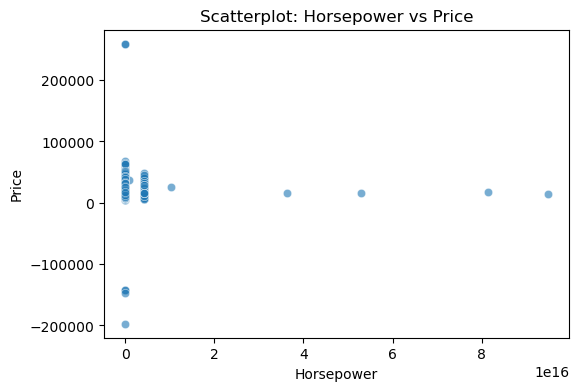

Correlation between Horsepower and Price:
            Horsepower   Price
Horsepower      1.0000 -0.0062
Price          -0.0062  1.0000


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("auto_price_cleaned.csv")

# (1) Scatterplot: Horsepower vs Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="Horsepower", y="Price", data=df, alpha=0.6)
plt.title("Scatterplot: Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

# Correlation
corr = df[["Horsepower","Price"]].corr()
print("Correlation between Horsepower and Price:")
print(corr)

### 4.2 histogram（dataset_A）

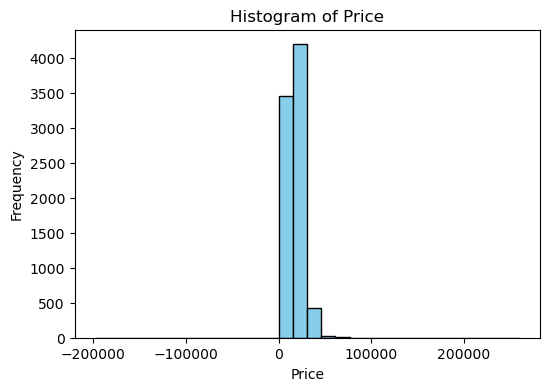

In [30]:
# (2) Histogram: Price
plt.figure(figsize=(6,4))
plt.hist(df["Price"].dropna(), bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# assignment_1_dataset_B

## 1 Import libraries and set file name

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# The file must sit in the same directory as this notebook
FILE_NAME = "diabetes_diagnosis.csv"

## 2 Load data and quick glance

In [2]:
# Load raw dataset
raw_df = pd.read_csv(FILE_NAME)

# Basic info
display(f"Raw shape: {raw_df.shape}")
display(raw_df.head())
display(raw_df.tail())

'Raw shape: (264802, 23)'

,Unnamed: 0,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,...,Physical (days),DiffWalk,Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic
0,0,NaN,40.0,NaN,NaN,0.0,NaN,NaN,NaN,1.0,...,15.0,NaN,NaN,63.0,High school graduate,"$73,106",No,Yes,Yes,No
1,1,NaN,25.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,...,NaN,NaN,Female,54.0,College graduate,"$22,322",No,No,No,No
2,2,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,High school graduate,"$29,097",No,Yes,Yes,NaN
3,3,1.0,27.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,74.0,Some high school,"$55,498",No,Yes,No,No
4,4,NaN,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,0.0,0.0,Female,NaN,Some college,"$15,629",No,Yes,NaN,No


,Unnamed: 0,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,...,Physical (days),DiffWalk,Sex,Age,Education,Income,Diabetes,BloodPressure,Cholesterol,Alcoholic
264797,264797,NaN,28.0,1.0,0.0,NaN,NaN,NaN,1.0,NaN,...,NaN,0.0,NaN,63.0,College graduate,"$14,166",No,NaN,Yes,Yes
264798,264798,1.0,27.0,NaN,0.0,NaN,1.0,NaN,NaN,1.0,...,0.0,NaN,Male,75.0,Some college,"$29,621",No,Yes,Yes,No
264799,264799,NaN,26.0,NaN,NaN,0.0,NaN,NaN,1.0,NaN,...,NaN,NaN,Female,-163.0,College graduate,"$38,234",No,NaN,No,No
264800,264800,1.0,23.0,NaN,NaN,0.0,NaN,0.0,NaN,1.0,...,0.0,NaN,Female,NaN,College graduate,"$15,659",No,No,No,No
264801,264801,NaN,37.0,NaN,0.0,NaN,NaN,0.0,NaN,1.0,...,NaN,0.0,NaN,48.0,High school graduate,"$63,709",No,No,No,NaN


## 3 Column meta-data (dtype, uniqueness, missingness)

In [3]:
# Build a concise "health table" for each column
summary = (raw_df
           .pipe(lambda df: pd.DataFrame({
               "dtype"      : df.dtypes.astype(str),
               "unique"     : df.nunique(dropna=False),
               "missing_cnt": df.isna().sum(),
               "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
           })))
display(summary)

,dtype,unique,missing_cnt,missing_pct
Unnamed: 0,int64,264802,0,0.0
CholCheck,float64,3,150937,57.0
BMI,float64,83,87384,33.0
Smoker,float64,5,119160,45.0
Stroke,float64,3,158881,60.0
HeartDiseaseorAttack,float64,3,71496,27.0
PhysActivity,float64,3,188009,71.0
Fruits,float64,5,161529,61.0
Veggies,float64,3,169473,64.0
AnyHealthcare,float64,3,182713,69.0


## 4 Problem definition
### Task description  
- **Goal**: Binary classification—predict diabetes status.  
- **Stakeholders**: public-health agencies, insurers, individuals.  
- **Motivation**: early detection lowers cost and improves outcomes.  
- **Stage-1 scope**: data understanding, cleaning, EDA—no modelling yet.

## 5 data cleaning

In [4]:
# Work on a copy to keep the original intact
clean_df = raw_df.copy()

# 5.1 Drop automatic index columns (e.g., 'Unnamed: 0')
clean_df = clean_df.loc[:, ~clean_df.columns.str.contains(r"^Unnamed")]

# 5.2 Strip leading/trailing spaces from string fields
for col in clean_df.select_dtypes("object"):
    clean_df[col] = clean_df[col].astype(str).str.strip()

# 5.3 Convert known categorical variables to category dtype
cat_cols = ["GeneralHealth", "Sex", "Education", "Income",
            "Diabetes", "BloodPressure", "Cholesterol", "Alcoholic"]
cat_cols = [c for c in cat_cols if c in clean_df.columns]
clean_df[cat_cols] = clean_df[cat_cols].astype("category")

# 5.4 Flag obvious outliers as missing
if "BMI" in clean_df:
    clean_df.loc[(clean_df["BMI"] < 10) | (clean_df["BMI"] > 80), "BMI"] = np.nan
if "Age" in clean_df:
    clean_df.loc[(clean_df["Age"] < 18) | (clean_df["Age"] > 99), "Age"] = np.nan
for col in ["PhysHealth", "MentHlth"]:
    if col in clean_df:
        clean_df.loc[(clean_df[col] < 0) | (clean_df[col] > 30), col] = np.nan

# 5.5 Persist cleaned file in the same folder
clean_file = "diabetes_diagnosis_clean.csv"
clean_df.to_csv(clean_file, index=False)
print("Cleaning done; saved as", clean_file)

Cleaning done; saved as diabetes_diagnosis_clean.csv


## 6 Histograms for numeric variables

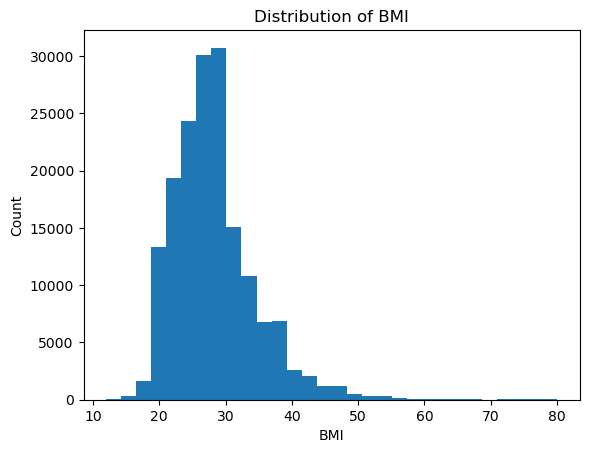

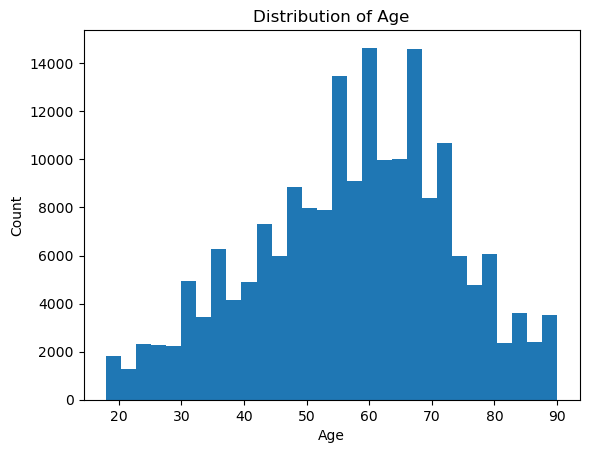

In [5]:
# Plot distributions for BMI and Age (if present)
num_cols = ["BMI", "Age"]
num_cols = [c for c in num_cols if c in clean_df.columns]

for col in num_cols:
    plt.figure()
    clean_df[col].dropna().plot(kind="hist", bins=30, title=f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 7 Bar charts for key categorical variables

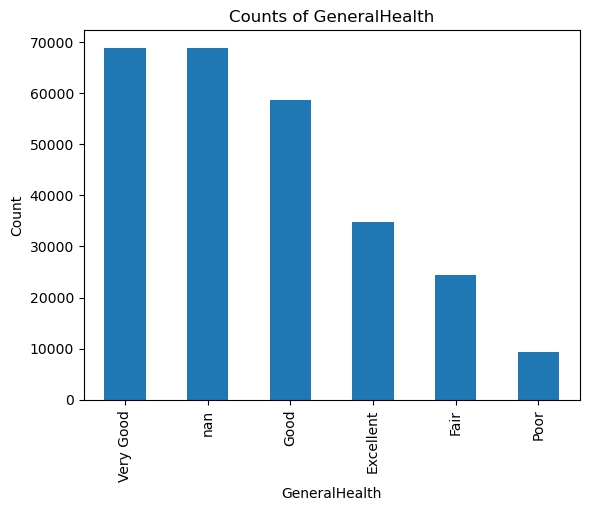

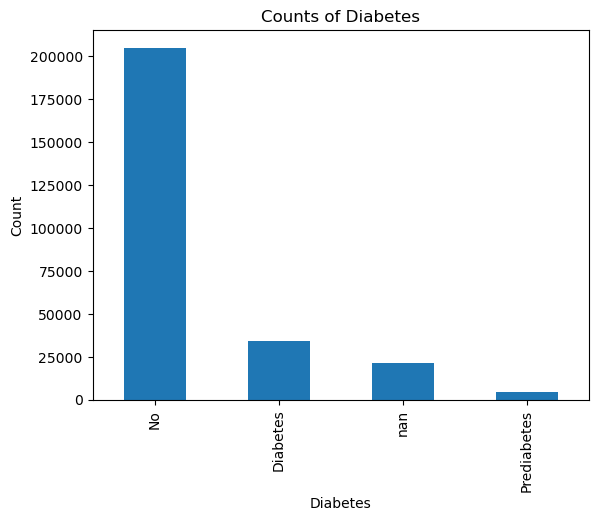

In [6]:
# Show value counts for GeneralHealth and Diabetes
cat_plot = ["GeneralHealth", "Diabetes"]
cat_plot = [c for c in cat_plot if c in clean_df.columns]

for col in cat_plot:
    plt.figure()
    clean_df[col].value_counts(dropna=False).plot(kind="bar", title=f"Counts of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 8 Cross-tabulation: Diabetes vs GeneralHealth

In [7]:
# Normalised crosstab to spot patterns
if {"Diabetes", "GeneralHealth"}.issubset(clean_df.columns):
    crosstab = pd.crosstab(clean_df["Diabetes"], clean_df["GeneralHealth"],
                           normalize="index").round(3)
    display(crosstab)

GeneralHealth,Excellent,Fair,Good,Poor,Very Good,nan
Diabetes,,,,,,
Diabetes,0.024,0.206,0.282,0.096,0.134,0.260
No,0.151,0.072,0.210,0.025,0.282,0.260
Prediabetes,0.052,0.164,0.280,0.053,0.200,0.250
nan,0.133,0.092,0.221,0.033,0.262,0.258


## 9 Quick sanity checks

In [8]:
# Ensure cleaned file exists and is not empty
assert Path(clean_file).exists(), f"{clean_file} was not created!"
assert len(clean_df) > 0, "Cleaned dataframe is empty!"
print(" All sanity checks passed—data loaded, cleaned and exported.")

 All sanity checks passed—data loaded, cleaned and exported.


## 10 Next-step reminder  
---
### Report checklist  
1. Dataset size, missingness percentage, data types.  
2. Cleaning steps & rationale (e.g., BMI / Age outlier rules).  
3. Key EDA findings: class balance, skewness, correlations.  
4. Link insights to business problem and next-stage modelling plan.
---

# assignment_1_dataset_c

## 1 Problem Definition_dataset C_forest cover
### 1.1 Define a business or research problem (classification/regression) based on dataset C.  
$~~$ The Forest Cover dataset contains geographical and environmental variables such as elevation, slope, distance to hydrology, and soil types. The target variable is Forest_Cover, which describes the type of dominant tree species in an area (e.g., Spruce/Fir, Lodgepole Pine, Aspen).  
$~~$ Therefore, I treat this as a classification problem, where the goal is to predict the forest cover type (categorical target variable) based on the environmental attributes.  
$~~$ The problem can be stated as: “Which numerical and categorical variables are most useful in predicting the type of forest cover?”  
### 1.2 Identify relevant stakeholders and explain how they benefit from solving the problem.  
$~~$ 1. Relevant stakeholders  
$~~~$ Forest managers and ecologists can use the predictions to understand habitat distribution and manage ecosystems better.  
$~~~$ Government agencies can use insights for land-use planning and conservation policies.  
$~~~$ Researchers can study how environmental factors influence vegetation patterns.  
$~~$ 2. Benefits  
$~~~$ Improves forest monitoring and sustainable management.  
$~~~$ Helps conservation projects by identifying ecological drivers of different forest types.  
$~~~$ Provides a foundation for predictive models in ecological and geographical research.

## 2 Data Description
### Conduct initial inspections of each dataset:
### 2.1 Number of attributes and instances

In [32]:
# 2: Initial Inspection of Forest Cover dataset
import pandas as pd

# Load dataset
df = pd.read_csv("forest_cover.csv")

# 2.1 Number of instances and attributes
print("Number of instances (rows):", df.shape[0])
print("Number of attributes (columns):", df.shape[1])

Number of instances (rows): 30860
Number of attributes (columns): 56


### 2.2 Data types of each attribute

In [33]:
# 2.2 Data types of each attribute
print("\nData types of each attribute:")
print(df.dtypes)


Data types of each attribute:
Unnamed: 0                              int64
Elevation                             float64
Aspect                                float64
Slope                                 float64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology        float64
Horizontal_Distance_To_Roadways       float64
Hillshade_9am                         float64
Hillshade_Noon                        float64
Hillshade_3pm                         float64
Horizontal_Distance_To_Fire_Points    float64
Soil_Type1                            float64
Soil_Type2                            float64
Soil_Type3                            float64
Soil_Type4                            float64
Soil_Type5                            float64
Soil_Type6                            float64
Soil_Type7                              int64
Soil_Type8                              int64
Soil_Type9                              int64
Soil_Type10                             int64
Soi

### 2.3 Presence and proportion of missing values

In [34]:
# 2.3 Presence and proportion of missing values
missing_counts = df.isnull().sum()
missing_ratio = (missing_counts / len(df)) * 100
missing_table = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing Ratio (%)": missing_ratio
})
print("\nMissing values summary:")
print(missing_table[missing_table["Missing Values"] > 0])


Missing values summary:
                                    Missing Values  Missing Ratio (%)
Elevation                                     4937          15.998056
Aspect                                        7097          22.997408
Slope                                         2777           8.998704
Horizontal_Distance_To_Hydrology              2468           7.997408
Vertical_Distance_To_Hydrology                1851           5.998056
Horizontal_Distance_To_Roadways               2468           7.997408
Hillshade_9am                                 9258          30.000000
Hillshade_Noon                                3703          11.999352
Hillshade_3pm                                 8640          27.997408
Horizontal_Distance_To_Fire_Points            5863          18.998704
Soil_Type1                                    5863          18.998704
Soil_Type2                                    2777           8.998704
Soil_Type3                                    5554          17.99

### 2.4 Unique values in categorical features

In [35]:
# 2.4 Unique values in categorical features
categorical_columns = df.select_dtypes(include=["object"]).columns
print("\nUnique values in categorical features:")
for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()[:10]}")

# show Forest_Cover data type
print("\nForest_Cover value counts:")
print(df["Forest_Cover"].value_counts())


Unique values in categorical features:
Forest_Cover: 7 unique values → ['Spruce/Fir' 'Lodgepole Pine' 'Ponderosa Pine' 'Aspen' 'Douglas-fir'
 'Krummholz' 'Cottonwood/Willow']

Forest_Cover value counts:
Forest_Cover
Lodgepole Pine       14945
Spruce/Fir           11391
Ponderosa Pine        1895
Krummholz             1060
Douglas-fir            939
Aspen                  489
Cottonwood/Willow      141
Name: count, dtype: int64


## 3.Data Cleaning and Processing

In [39]:
# Step 3: Data Cleaning and Processing
import pandas as pd
import numpy as np

# 读取数据集
df = pd.read_csv("forest_cover.csv")

### 3.1 check the data

In [40]:
# 3.1 Identify data quality issues
# Print the original dataset shape
print("Original dataset shape:", df.shape)

# Show the data types of each column
print("\nData types:")
print(df.dtypes)

# Check missing values per column
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("\nMissing values summary:")
print(missing_values)

Original dataset shape: (30860, 56)

Data types:
Unnamed: 0                              int64
Elevation                             float64
Aspect                                float64
Slope                                 float64
Horizontal_Distance_To_Hydrology      float64
Vertical_Distance_To_Hydrology        float64
Horizontal_Distance_To_Roadways       float64
Hillshade_9am                         float64
Hillshade_Noon                        float64
Hillshade_3pm                         float64
Horizontal_Distance_To_Fire_Points    float64
Soil_Type1                            float64
Soil_Type2                            float64
Soil_Type3                            float64
Soil_Type4                            float64
Soil_Type5                            float64
Soil_Type6                            float64
Soil_Type7                              int64
Soil_Type8                              int64
Soil_Type9                              int64
Soil_Type10                    

### 3.2 strategy of data cleaning

In [43]:
# 3.2 Apply cleaning strategies

# Drop columns with more than 50% missing values
# Use errors="ignore" so that if a column is not found, it will be skipped
high_missing_cols = [
    'Soil_Type20','Soil_Type29','Soil_Type31','Soil_Type36','Soil_Type37',
    'Soil_Type19','Soil_Type30','Soil_Type26','Soil_Type12','Soil_Type33'
]
df.drop(columns=high_missing_cols, inplace=True, errors="ignore")
print("\nDropped columns with too many missing values (if present):", high_missing_cols)

# Handle missing values in numerical columns by mean imputation
# Mean is chosen because these are continuous environmental features
num_cols = df.select_dtypes(include=['float64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:  # only impute if missing values exist
        df[col] = df[col].fillna(df[col].mean())

# Convert Soil_Type columns to integers (binary 0/1 instead of float)
soil_cols = [col for col in df.columns if "Soil_Type" in col]
df[soil_cols] = df[soil_cols].astype(int)

# Remove redundant column "Unnamed: 0" if it exists
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Convert target variable Forest_Cover to categorical type
df["Forest_Cover"] = df["Forest_Cover"].astype("category")


Dropped columns with too many missing values (if present): ['Soil_Type20', 'Soil_Type29', 'Soil_Type31', 'Soil_Type36', 'Soil_Type37', 'Soil_Type19', 'Soil_Type30', 'Soil_Type26', 'Soil_Type12', 'Soil_Type33']


### 3.3 Ensure data is ready for modelling

In [44]:
# 3.3 Ensure data is ready for modelling
print("\nCleaned dataset shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())  # Should print 0 if all missing values handled


Cleaned dataset shape: (30860, 45)

Missing values after cleaning:
0


### 3.4 Feature engineering

In [45]:
# 3.4 Feature engineering
# Create a combined distance to hydrology
if {"Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"}.issubset(df.columns):
    df["Total_Distance_To_Hydrology"] = (df["Horizontal_Distance_To_Hydrology"] + df["Vertical_Distance_To_Hydrology"])

# Create an average hillshade variable
if {"Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm"}.issubset(df.columns):
    df["Avg_Hillshade"] = (
        df["Hillshade_9am"] + df["Hillshade_Noon"] + df["Hillshade_3pm"]
    ) / 3

# Save the cleaned dataset for later use
df.to_csv("forest_cover_cleaned.csv", index=False)
print("\nCleaned dataset saved as forest_cover_cleaned.csv")


Cleaned dataset saved as forest_cover_cleaned.csv


## 4.Exploratory Data Analysis
### 4.1 Scatterplot with correlation

Pearson correlation (Elevation vs Slope): -0.011


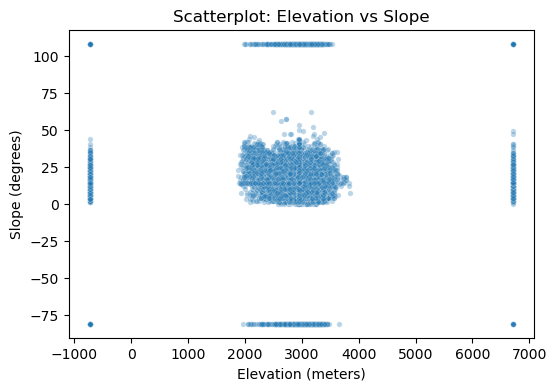

In [46]:
# Step 4: Exploratory Data Analysis (EDA)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned dataset
df = pd.read_csv("forest_cover_cleaned.csv")

# Select features
# Numerical: Elevation, Slope
# Categorical: Forest_Cover (target)

# 4.1 Scatterplot with correlation
# Correlation between Elevation and Slope
corr = df["Elevation"].corr(df["Slope"])
print("Pearson correlation (Elevation vs Slope):", round(corr, 3))

# Scatterplot of Elevation vs Slope
plt.figure(figsize=(6,4))
sns.scatterplot(x="Elevation", y="Slope", data=df, alpha=0.3, s=15)
plt.title("Scatterplot: Elevation vs Slope")
plt.xlabel("Elevation (meters)")
plt.ylabel("Slope (degrees)")
plt.show()

### 4.2 Bar plot: Average Elevation by Forest_Cover

C:\Users\fwy\AppData\Local\Temp\ipykernel_14892\2515377807.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Forest_Cover", y="Elevation", data=df, estimator="mean", ci=None, palette="viridis")
C:\Users\fwy\AppData\Local\Temp\ipykernel_14892\2515377807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Forest_Cover", y="Elevation", data=df, estimator="mean", ci=None, palette="viridis")


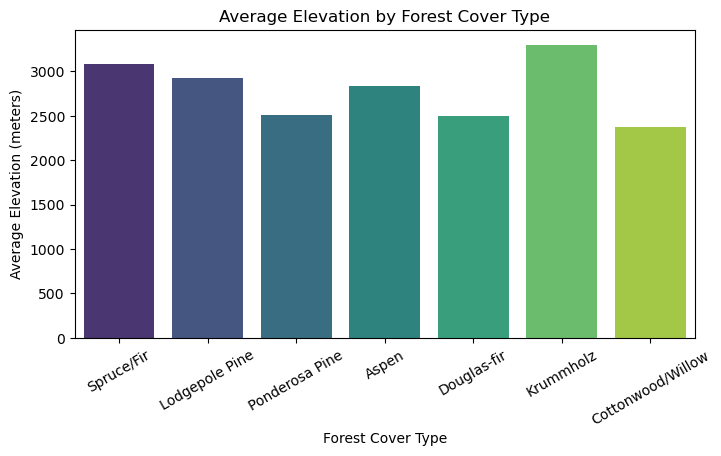

In [47]:
# 4.2 Bar plot: Average Elevation by Forest_Cover
plt.figure(figsize=(8,4))
sns.barplot(x="Forest_Cover", y="Elevation", data=df, estimator="mean", ci=None, palette="viridis")
plt.title("Average Elevation by Forest Cover Type")
plt.xlabel("Forest Cover Type")
plt.ylabel("Average Elevation (meters)")
plt.xticks(rotation=30)
plt.show()